<h1> ______________________________________ </h1>

<h1> Full NEXT100 with fiber panels simulation signal analysis </h1>
<h1> ______________________________________ </h1>

<p style="font-size: 17px; color: black;"> In this Notebook we take as input the signal created in the previous notebook and use it to analize the waveforms. </p>




In [1]:
# S2 signal script
import sys
sys.path.append('/home/investigator/mariandbt/python/notebooks/modules')

from import_modules import *

import set_up as setup
import s2_hists as s2hist


In [2]:
# Data reading
# ________________________________________________________________________________________________________________

path = '/home/investigator/mariandbt/python/data'
# path = path + '/20231025_NEXT100_full_mapping'
path = path + '/20240313_s2simulation'


# off_s2_file_path = os.path.join(path, "20240219_bb0nu_200ev_s2_signal.h5") # has fluctuations
# off_s2_file_path = os.path.join(path, "20240222_bb0nu_200ev_s2_signal.h5") # has fluctuations
# off_s2_file_path = os.path.join(path, "20240226_bb0nu_200ev_s2_signal.h5") # has fluctuations
# off_s2_file_path = os.path.join(path, "20240228_bb0nu_10ev_ELon_s2_signal.h5") # EL ON + fluctuations

# online_s2_filename = os.path.join(path, "next100_fibers/20240122_Next100_bb_1.next.h5") # 1 full bb w s2
# online_s2_filename = os.path.join(path, "next100_fibers/20240226_Next100_bb_1.next.h5") # 10 full bb w s2

# off_s2_file_path = os.path.join(path, "s2signals/20240314_bb0nu_10ev_ELon_s2_signal_20240304s2table.h5") # EL ON + fluctuations
# online_s2_filename = os.path.join(path, "bb/20240228_Next100_10ev_ELon_bb_1.next.h5") # 10 full bb w s2

# off_s2_file_path = os.path.join(path, "s2signals/20240315_bb0nu_2000ev_ELoff_s2_signal_20240304s2table.h5") # fluctuations
# off_s2_file_path = os.path.join(path, "s2signals/20240318_bb0nu_200ev_ELoff_s2_signal_20240304s2table.h5") # fluctuations
# off_s2_file_path = os.path.join(path, "s2signals/20240318_bb0nu_2000ev_ELoff_s2_signal_20240304s2table.h5") # fluctuations
# off_s2_file_path = os.path.join(path, "s2signals/20240405_bb0nu_2000ev_ELoff_s2_signal_20240405s2table.h5") # 6sens + fluctuations
off_s2_file_path = os.path.join(path, "s2signals/20240503_bb0nu_2Kev_ELoff_s2_signal_shaped155ns_sampled25ns_20240405s2table.h5") # 6sens + fluctuations
# off_s2_file_path = os.path.join(path, "s2signals/20240503_bb0nuTEST_alltimeinfo_1ev_ELoff_s2_signal_shaped20ns_sampled25ns_20240405s2table.h5") # 6sens + fluctuations

list_of_offline_s2_file_paths = [off_s2_file_path]
 
# sns_positions, sns_response = setup.read_fiber_sens(online_s2_filename)

print("""
        NOTE: if you want to compare online and offline waveforms 
        it should be done with the offline file and the original online file from which this was created
      """)


        NOTE: if you want to compare online and offline waveforms 
        it should be done with the offline file and the original online file from which this was created
      


In [3]:
setup.check_h5(off_s2_file_path)


KeyboardInterrupt: 

In [ ]:
def build_offline_s2_max_dict(list_of_offline_s2_file_paths, samplin_rate_in_us = 1):

    # Max value of the s2 signals dictionary building
    s2_max_dict = {} # max s2 peak per event
    prim_e_r_dict = {} # radial coordinate of each event
    n_event = 0

    for offline_s2_file_path in list_of_offline_s2_file_paths:
        # Open the HDF5 file in read mode
        with h5py.File(offline_s2_file_path, 'r') as file:
            # Iterate through the top-level keys (groups) in the HDF5 file
            for event in file.keys():
                # Get the group corresponding to the current event
                event_group = file[event]

                s2_max = []

                print(f'Event {event} processed')

                # Iterate through the sensors (datasets) in the current group
                for sensor in event_group.keys():

                    # Get and print the value corresponding to the current sensor
                    signal = event_group[sensor]

                    prim_e_r = np.array(signal['prim_e_r_in_mm']) # [mm]
                    s2 = np.array(signal['s2_in_pes']) # [pes]
                    original_samplin_rate_in_us = np.array(signal['samplin_rate_in_ns'])*1e-3 # [us]

                    if prim_e_r > fiducial_radio:
                        continue

                    samplin_step = int(samplin_rate_in_us//original_samplin_rate_in_us)

                    s2_shaped_sampled  = s2[::samplin_step]
                    s2_max.append(s2_shaped_sampled.max()) # peak of s2 signal per sensor


                if prim_e_r > fiducial_radio:
                    print('Discarded event by fiducial cut')
                    continue

                s2_max_dict[n_event] = max(s2_max) # max s2 peak from all sensors
                prim_e_r_dict[n_event] = prim_e_r # radial coordinate of each event

                n_event = n_event + 1

            n_sensors = len(event_group.keys()) # all events have all sensors, just get the last one

    setup.create_or_update_global_variable(globals(), 'n_sensors', n_sensors, verbose = True)

    return s2_max_dict, prim_e_r_dict

In [42]:
for offline_s2_file_path in list_of_offline_s2_file_paths:
    # Open the HDF5 file in read mode
    with h5py.File(offline_s2_file_path, 'r') as file:
        # Iterate through the top-level keys (groups) in the HDF5 file
        for event in list(file.keys())[:10]:
            # Get the group corresponding to the current event
            event_group = file[event]

            s2_max = []

            print(f'Event {event} processed')

            # Iterate through the sensors (datasets) in the current group
            for sensor in event_group.keys():

                # Get and print the value corresponding to the current sensor
                signal = event_group[sensor]
#                 print(signal.keys())
                s2 = np.array(signal['s2_in_pes'])

Event 0 processed
Event 1 processed
Event 10 processed
Event 100 processed
Event 1000 processed
Event 1001 processed
Event 1002 processed
Event 1003 processed
Event 1004 processed
Event 1005 processed


In [3]:
s2tab_path = os.path.join(path, "s2tab/20240405_s2_table.h5")
setup.check_h5(s2tab_path)


/home/investigator/mariandbt/python/data/20240313_s2simulation/s2tab/20240405_s2_table.h5 (File) ''
Last modif.: '2024-04-12T08:49:58+00:00'
Object Tree: 
/ (RootGroup) ''
/sens_200 (Array(784, 5)) ''
/sens_201 (Array(784, 5)) ''
/sens_202 (Array(784, 5)) ''
/sens_203 (Array(784, 5)) ''
/sens_204 (Array(784, 5)) ''
/sens_205 (Array(784, 5)) ''
/sens_206 (Array(784, 5)) ''
/sens_207 (Array(784, 5)) ''
/sens_208 (Array(784, 5)) ''
/sens_209 (Array(784, 5)) ''
/sens_210 (Array(784, 5)) ''
/sens_211 (Array(784, 5)) ''
/sens_212 (Array(784, 5)) ''
/sens_213 (Array(784, 5)) ''
/sens_214 (Array(784, 5)) ''
/sens_215 (Array(784, 5)) ''
/sens_216 (Array(784, 5)) ''
/sens_217 (Array(784, 5)) ''
/sens_218 (Array(784, 5)) ''
/sens_219 (Array(784, 5)) ''
/sens_220 (Array(784, 5)) ''
/sens_221 (Array(784, 5)) ''
/sens_222 (Array(784, 5)) ''
/sens_223 (Array(784, 5)) ''
/sens_224 (Array(784, 5)) ''
/sens_225 (Array(784, 5)) ''
/sens_226 (Array(784, 5)) ''
/sens_227 (Array(784, 5)) ''
/sens_228 (Array

In [4]:
ie_path = os.path.join(path, "ie/20240405_Next100_ie_s2_1.next.h5")
setup.check_h5(ie_path)
sns_pos, sns_resp = setup.read_fiber_sens(ie_path)

/home/investigator/mariandbt/python/data/20240313_s2simulation/ie/20240405_Next100_ie_s2_1.next.h5 (File) ''
Last modif.: '2024-04-11T10:57:45+00:00'
Object Tree: 
/ (RootGroup) ''
/MC (Group) ''
/MC/configuration (Table(51,)) ''
/MC/hits (Table(0,)) ''
/MC/particles (Table(100000,)) ''
/MC/sns_positions (Table(3487,)) ''
/MC/sns_response (Table(1429848,)) ''



/home/investigator/miniconda3/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/pandas/io/pytables.py:3523: IncompatibilityWarning: 
where criteria is being ignored as this version [0.0.0] is too old (or
not-defined), read the file in and write it out to a new file to upgrade (with
the copy_to method)

  warnings.warn(ws, IncompatibilityWarning)


In [39]:
# Global params
# ________________________________________________________________________________________________________________

t_binnin = 0.1 # [ns] Conversion constant from bin enumerations to nanoseconds (binning used in the simulation)
fiducial_radio = 490 # [mm]
# fiducial_radio = 400 # [mm]
# bin_width_in_us = 25e-3 # [us] = 25 [ns]
bin_width_in_us = 1 # [us] 

In [40]:
s2hist.set_global_parameters(globals(), t_binnin, fiducial_radio)

t_binnin already exists! Updating variable.
t_binnin already exists! Updating variable.
fiducial_radio already exists! Updating variable.
Global parameters set successfully :)


In [41]:
# s2_max_dict, prim_e_r_dict = s2hist.build_offline_s2_max_dict(off_s2_file_path, bin_width_in_us)

In [42]:
# rise_time, tau

In [43]:
s2_max_dict, prim_e_r_dict  = s2hist.build_offline_s2_max_dict(list_of_offline_s2_file_paths, 
                                                               samplin_rate_in_us = 1)


Event 1/1963 processed in file 1/1
Event 2/1963 processed in file 1/1
Event 3/1963 processed in file 1/1
Event 4/1963 processed in file 1/1
Event 5/1963 processed in file 1/1
Event 6/1963 processed in file 1/1
Event 7/1963 processed in file 1/1
Event 8/1963 processed in file 1/1
Event 9/1963 processed in file 1/1
Event 10/1963 processed in file 1/1
Event 11/1963 processed in file 1/1
Event 12/1963 processed in file 1/1
Event 13/1963 processed in file 1/1
Event 14/1963 processed in file 1/1
Event 15/1963 processed in file 1/1
Event 16/1963 processed in file 1/1
Event 17/1963 processed in file 1/1
Event 18/1963 processed in file 1/1
Event 19/1963 processed in file 1/1
Event 20/1963 processed in file 1/1
Event 21/1963 processed in file 1/1
Event 22/1963 processed in file 1/1
Event 23/1963 processed in file 1/1
Event 24/1963 processed in file 1/1
Event 25/1963 processed in file 1/1
Event 26/1963 processed in file 1/1
Event 27/1963 processed in file 1/1
Event 28/1963 processed in file 1/1
E

Event 227/1963 processed in file 1/1
Event 228/1963 processed in file 1/1
Event 229/1963 processed in file 1/1
Event 230/1963 processed in file 1/1
Event 231/1963 processed in file 1/1
Event 232/1963 processed in file 1/1
Event 233/1963 processed in file 1/1
Event 234/1963 processed in file 1/1
Event 235/1963 processed in file 1/1
Event 236/1963 processed in file 1/1
Event 237/1963 processed in file 1/1
Event 238/1963 processed in file 1/1
Event 239/1963 processed in file 1/1
Event 240/1963 processed in file 1/1
Event 241/1963 processed in file 1/1
Event 242/1963 processed in file 1/1
Event 243/1963 processed in file 1/1
Event 244/1963 processed in file 1/1
Event 245/1963 processed in file 1/1
Event 246/1963 processed in file 1/1
Event 247/1963 processed in file 1/1
Event 248/1963 processed in file 1/1
Event 249/1963 processed in file 1/1
Event 250/1963 processed in file 1/1
Event 251/1963 processed in file 1/1
Event 252/1963 processed in file 1/1
Event 253/1963 processed in file 1/1
E

Event 451/1963 processed in file 1/1
Event 452/1963 processed in file 1/1
Event 453/1963 processed in file 1/1
Event 454/1963 processed in file 1/1
Event 455/1963 processed in file 1/1
Event 456/1963 processed in file 1/1
Event 457/1963 processed in file 1/1
Event 458/1963 processed in file 1/1
Event 459/1963 processed in file 1/1
Event 460/1963 processed in file 1/1
Event 461/1963 processed in file 1/1
Event 462/1963 processed in file 1/1
Event 463/1963 processed in file 1/1
Event 464/1963 processed in file 1/1
Event 465/1963 processed in file 1/1
Event 466/1963 processed in file 1/1
Event 467/1963 processed in file 1/1
Event 468/1963 processed in file 1/1
Event 469/1963 processed in file 1/1
Event 470/1963 processed in file 1/1
Event 471/1963 processed in file 1/1
Event 472/1963 processed in file 1/1
Event 473/1963 processed in file 1/1
Event 474/1963 processed in file 1/1
Event 475/1963 processed in file 1/1
Event 476/1963 processed in file 1/1
Event 477/1963 processed in file 1/1
E

Event 675/1963 processed in file 1/1
Event 676/1963 processed in file 1/1
Event 677/1963 processed in file 1/1
Event 678/1963 processed in file 1/1
Event 679/1963 processed in file 1/1
Event 680/1963 processed in file 1/1
Event 681/1963 processed in file 1/1
Event 682/1963 processed in file 1/1
Event 683/1963 processed in file 1/1
Event 684/1963 processed in file 1/1
Event 685/1963 processed in file 1/1
Event 686/1963 processed in file 1/1
Event 687/1963 processed in file 1/1
Event 688/1963 processed in file 1/1
Event 689/1963 processed in file 1/1
Event 690/1963 processed in file 1/1
Event 691/1963 processed in file 1/1
Event 692/1963 processed in file 1/1
Event 693/1963 processed in file 1/1
Event 694/1963 processed in file 1/1
Event 695/1963 processed in file 1/1
Event 696/1963 processed in file 1/1
Event 697/1963 processed in file 1/1
Event 698/1963 processed in file 1/1
Event 699/1963 processed in file 1/1
Event 700/1963 processed in file 1/1
Event 701/1963 processed in file 1/1
E

Event 900/1963 processed in file 1/1
Event 901/1963 processed in file 1/1
Event 902/1963 processed in file 1/1
Event 903/1963 processed in file 1/1
Event 904/1963 processed in file 1/1
Event 905/1963 processed in file 1/1
Event 906/1963 processed in file 1/1
Event 907/1963 processed in file 1/1
Event 908/1963 processed in file 1/1
Event 909/1963 processed in file 1/1
Event 910/1963 processed in file 1/1
Event 911/1963 processed in file 1/1
Event 912/1963 processed in file 1/1
Event 913/1963 processed in file 1/1
Event 914/1963 processed in file 1/1
Event 915/1963 processed in file 1/1
Event 916/1963 processed in file 1/1
Event 917/1963 processed in file 1/1
Event 918/1963 processed in file 1/1
Event 919/1963 processed in file 1/1
Event 920/1963 processed in file 1/1
Event 921/1963 processed in file 1/1
Event 922/1963 processed in file 1/1
Event 923/1963 processed in file 1/1
Event 924/1963 processed in file 1/1
Event 925/1963 processed in file 1/1
Event 926/1963 processed in file 1/1
E

Event 1122/1963 processed in file 1/1
Event 1123/1963 processed in file 1/1
Event 1124/1963 processed in file 1/1
Event 1125/1963 processed in file 1/1
Event 1126/1963 processed in file 1/1
Event 1127/1963 processed in file 1/1
Event 1128/1963 processed in file 1/1
Event 1129/1963 processed in file 1/1
Event 1130/1963 processed in file 1/1
Event 1131/1963 processed in file 1/1
Event 1132/1963 processed in file 1/1
Event 1133/1963 processed in file 1/1
Event 1134/1963 processed in file 1/1
Event 1135/1963 processed in file 1/1
Event 1136/1963 processed in file 1/1
Event 1137/1963 processed in file 1/1
Event 1138/1963 processed in file 1/1
Event 1139/1963 processed in file 1/1
Event 1140/1963 processed in file 1/1
Event 1141/1963 processed in file 1/1
Event 1142/1963 processed in file 1/1
Event 1143/1963 processed in file 1/1
Event 1144/1963 processed in file 1/1
Event 1145/1963 processed in file 1/1
Event 1146/1963 processed in file 1/1
Event 1147/1963 processed in file 1/1
Event 1148/1

Event 1340/1963 processed in file 1/1
Event 1341/1963 processed in file 1/1
Event 1342/1963 processed in file 1/1
Event 1343/1963 processed in file 1/1
Event 1344/1963 processed in file 1/1
Event 1345/1963 processed in file 1/1
Event 1346/1963 processed in file 1/1
Event 1347/1963 processed in file 1/1
Event 1348/1963 processed in file 1/1
Event 1349/1963 processed in file 1/1
Event 1350/1963 processed in file 1/1
Event 1351/1963 processed in file 1/1
Event 1352/1963 processed in file 1/1
Event 1353/1963 processed in file 1/1
Event 1354/1963 processed in file 1/1
Event 1355/1963 processed in file 1/1
Event 1356/1963 processed in file 1/1
Event 1357/1963 processed in file 1/1
Event 1358/1963 processed in file 1/1
Event 1359/1963 processed in file 1/1
Event 1360/1963 processed in file 1/1
Event 1361/1963 processed in file 1/1
Event 1362/1963 processed in file 1/1
Event 1363/1963 processed in file 1/1
Event 1364/1963 processed in file 1/1
Event 1365/1963 processed in file 1/1
Event 1366/1

Event 1560/1963 processed in file 1/1
Event 1561/1963 processed in file 1/1
Event 1562/1963 processed in file 1/1
Event 1563/1963 processed in file 1/1
Event 1564/1963 processed in file 1/1
Event 1565/1963 processed in file 1/1
Event 1566/1963 processed in file 1/1
Event 1567/1963 processed in file 1/1
Event 1568/1963 processed in file 1/1
Event 1569/1963 processed in file 1/1
Event 1570/1963 processed in file 1/1
Event 1571/1963 processed in file 1/1
Event 1572/1963 processed in file 1/1
Event 1573/1963 processed in file 1/1
Event 1574/1963 processed in file 1/1
Event 1575/1963 processed in file 1/1
Event 1576/1963 processed in file 1/1
Event 1577/1963 processed in file 1/1
Event 1578/1963 processed in file 1/1
Event 1579/1963 processed in file 1/1
Event 1580/1963 processed in file 1/1
Event 1581/1963 processed in file 1/1
Event 1582/1963 processed in file 1/1
Event 1583/1963 processed in file 1/1
Event 1584/1963 processed in file 1/1
Event 1585/1963 processed in file 1/1
Event 1586/1

Event 1778/1963 processed in file 1/1
Event 1779/1963 processed in file 1/1
Event 1780/1963 processed in file 1/1
Event 1781/1963 processed in file 1/1
Event 1782/1963 processed in file 1/1
Event 1783/1963 processed in file 1/1
Event 1784/1963 processed in file 1/1
Event 1785/1963 processed in file 1/1
Event 1786/1963 processed in file 1/1
Event 1787/1963 processed in file 1/1
Event 1788/1963 processed in file 1/1
Event 1789/1963 processed in file 1/1
Event 1790/1963 processed in file 1/1
Event 1791/1963 processed in file 1/1
Event 1792/1963 processed in file 1/1
Event 1793/1963 processed in file 1/1
Event 1794/1963 processed in file 1/1
Event 1795/1963 processed in file 1/1
Event 1796/1963 processed in file 1/1
Event 1797/1963 processed in file 1/1
Event 1798/1963 processed in file 1/1
Event 1799/1963 processed in file 1/1
Event 1800/1963 processed in file 1/1
Event 1801/1963 processed in file 1/1
Event 1802/1963 processed in file 1/1
Event 1803/1963 processed in file 1/1
Event 1804/1

<Figure size 640x480 with 0 Axes>

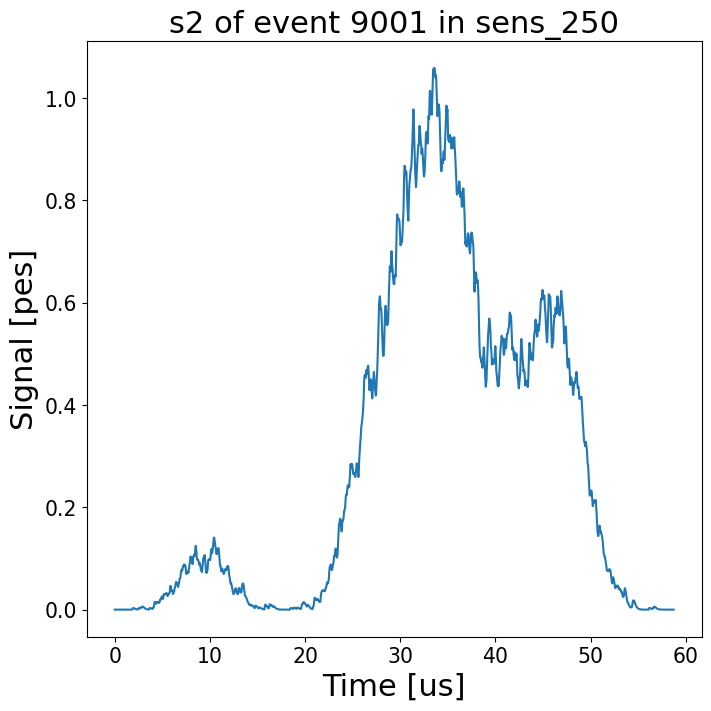

In [45]:
event = 9001
sensor = 250
# sensor = all
bin_width = 25e-3 # [us]

events_off_TEST7, bins_off, ax = s2hist.print_offline_s2waveform(off_s2_file_path, event, sensor, 
                                                                t0_in_us = 0, 
                                                                samplin_rate_in_us = bin_width, 
                                                                new_figure = False, 
                                                                 comment = r'6 sensors with GOOD shaping ($\tau$ = 200 [ns])')


<Figure size 640x480 with 0 Axes>

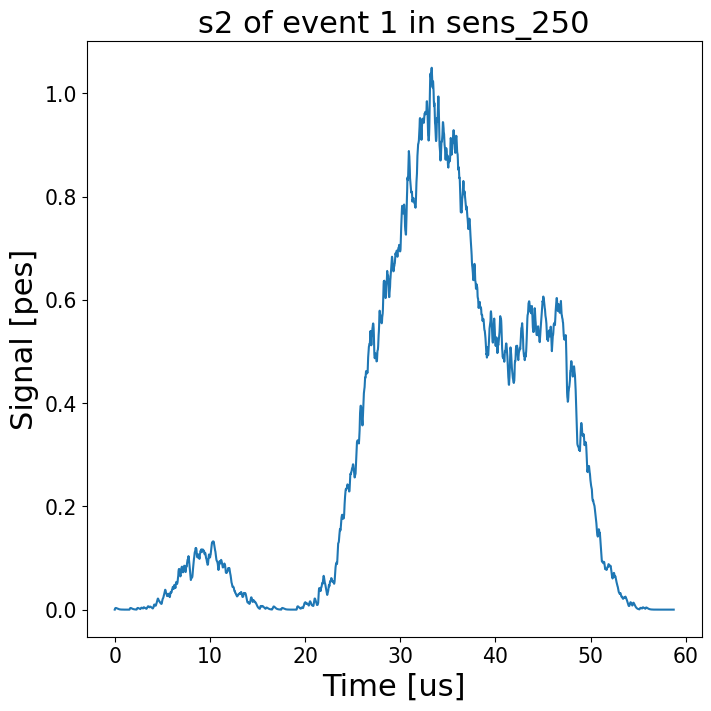

In [28]:
event = 1
sensor = 250
# sensor = all
bin_width = 25e-3 # [us]

events_off_TEST7, bins_off, ax = s2hist.print_offline_s2waveform(off_s2_file_path, event, sensor, 
                                                                t0_in_us = 0, 
                                                                samplin_rate_in_us = bin_width, 
                                                                new_figure = False, 
                                                                 comment = r'6 sensors with GOOD shaping ($\tau$ = 200 [ns])')


In [12]:
# off_s2_file_path_1 = os.path.join(path, "s2signals/20240315_bb0nu_2000ev_ELoff_s2_signal_20240304s2table.h5") # fluctuations
# off_s2_file_path_2 = os.path.join(path, "s2signals/20240318_bb0nu_200ev_ELoff_s2_signal_20240304s2table.h5") # fluctuations

# off_s2_file_path_list = [off_s2_file_path_1, off_s2_file_path_2]
# # off_s2_file_path_list = [off_s2_file_path]

# s2_max_dict = {}
# prim_e_r_dict = {}

# for off_s2_file_path in off_s2_file_path_list:
#     s2_max_dict_this_file, prim_e_r_dict_this_file = s2hist.build_offline_s2_max_dict(off_s2_file_path, 
#                                                                                       bin_width_in_us)
#     s2_max_dict = {**s2_max_dict, **s2_max_dict_this_file}
#     prim_e_r_dict = {**prim_e_r_dict, **prim_e_r_dict_this_file}

# # print(s2_max_dict)


In [47]:
def conversion_to_mV(waveform_in_pes_per_ns, impedance_in_ohm):
    
    sipm_gain = 4e6 # e/pes
    e_charge = 1.6e-19 # C/e
    
    pes_to_C = sipm_gain*e_charge # C/pes
    ns_to_s = 1e-9 # s/ns
    
    waveform_in_V = waveform_in_pes_per_ns*(pes_to_C/ns_to_s)*impedance_in_ohm # V
    waveform_in_mV = waveform_in_V*1e3 # mV
    
    return waveform_in_mV

In [60]:
conversion_to_mV(1, 50)

32.0

In [55]:
s2_max_dict_mV = {}
for key, value in s2_max_dict.items():
    s2_max_dict_mV[key] = conversion_to_mV(s2_max_dict[key], 50)

Text(0.5, 0, 's2 signal max [mV]')

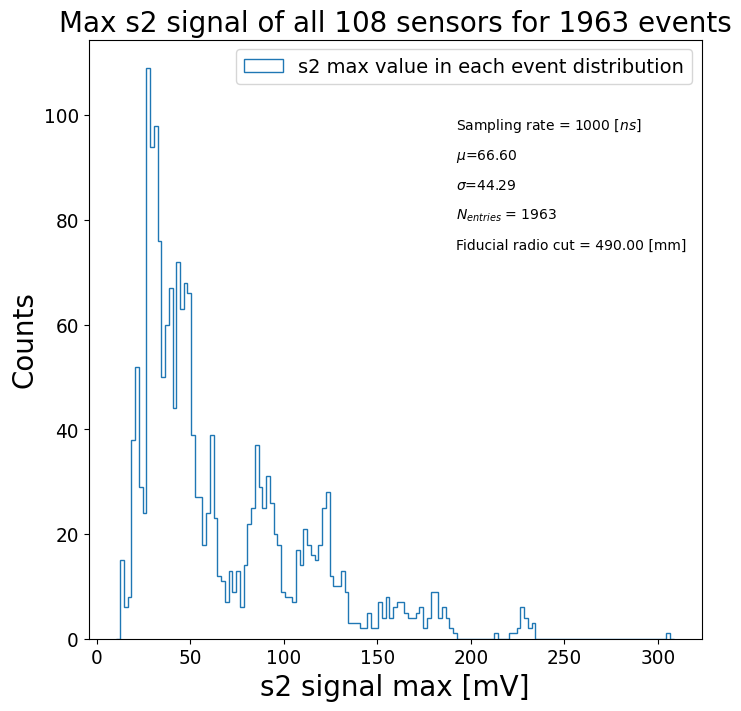

In [59]:
events, bin_edges, ax = s2hist.print_dyn_range_hist(s2_max_dict_mV, bin_width_in_pes = 2)

# font_size = 20

ax.text(0.6, .85, r'Sampling rate = %.0f [$ns$]'%(bin_width_in_us*1000),
transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='1.', edgecolor='none', pad=3.0));
ax.set_yscale('linear')
ax.set_xlabel('s2 signal max [mV]')

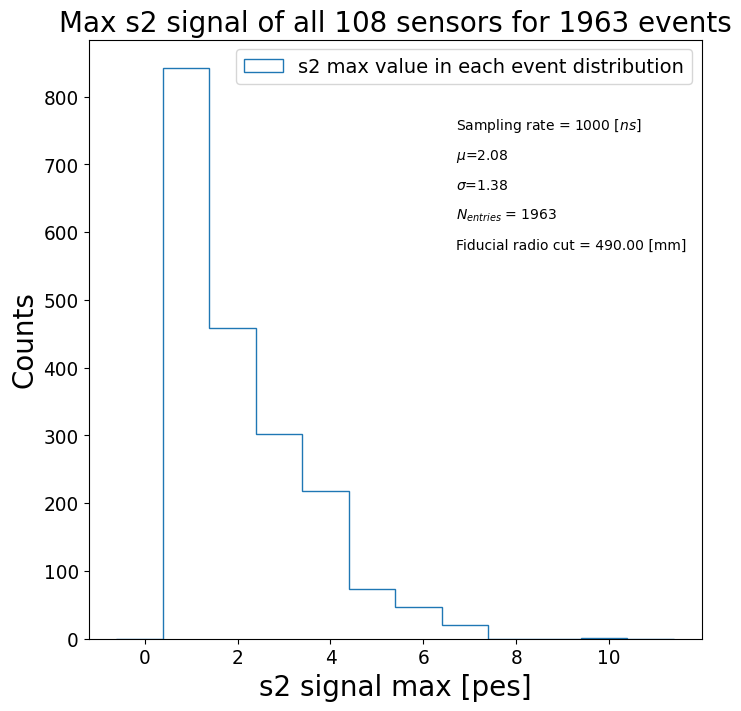

In [46]:
events, bin_edges, ax = s2hist.print_dyn_range_hist(s2_max_dict, bin_width_in_pes = 1)

# font_size = 20

ax.text(0.6, .85, r'Sampling rate = %.0f [$ns$]'%(bin_width_in_us*1000),
transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='1.', edgecolor='none', pad=3.0));
ax.set_yscale('linear')


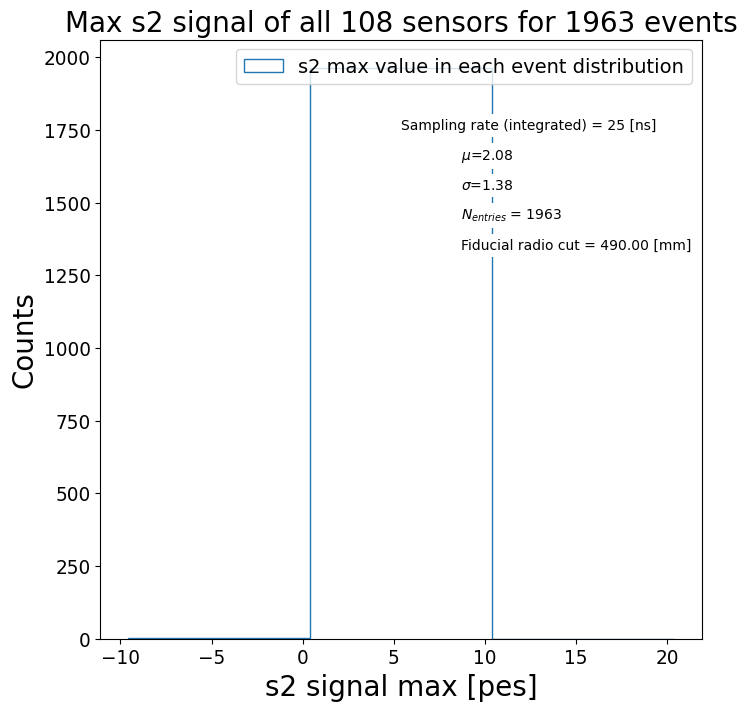

In [11]:
events, bin_edges, ax = s2hist.print_dyn_range_hist(s2_max_dict, bin_width_in_pes = 10)

# font_size = 20

ax.text(0.5, .85, 'Sampling rate (integrated) = %.0f [ns]'%(bin_width_in_us*1000),
transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))
ax.set_yscale('linear')


In [ ]:
s2

In [ ]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(15,10), constrained_layout=True)

s2 = np.array(list(s2_max_dict.values()))

# Create a histogram
events, bin_ref = np.histogram(s2, bins=bin_edges)

# Plot the histogram
ax.hist((bin_ref[1:] + bin_ref[:-1])/2, bins=bin_ref,
         weights = events, 
         alpha=1)


s2 = s2[s2 < 200]
events, bins = np.histogram(s2, bins=bin_ref)
ax.hist((bins[1:] + bins[:-1])/2, bins=bin_ref,
         weights = events, 
         alpha=0.7)

ax.set_title('Histogram')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')

In [ ]:
def signal_cut_eff(s2_max_dict, bin_width_in_pes, cuts):
    
    # Create a histogram
    s2 = np.array(list(s2_max_dict.values()))
    bin_edges = np.arange(s2.min() - bin_width_in_pes, s2.max() + 2*bin_width_in_pes, bin_width_in_pes)

    events_ref, bin_ref = np.histogram(s2, bins=bin_edges)

    eff_dict = {}

    for ii, cut in enumerate(cuts):

        s2 = s2[s2 < cut]
        events, bins = np.histogram(s2, bins=bin_ref)

        eff = events.sum()*100/events_ref.sum()

        eff_dict[cut] = eff

    
    return eff_dict

In [ ]:
def print_signal_cut_eff(s2_max_dict, bin_width_in_pes, cuts):
    
    fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(7, 7), constrained_layout=True)

    # Create a histogram
    s2 = np.array(list(s2_max_dict.values()))
    bin_edges = np.arange(s2.min() - bin_width_in_pes, s2.max() + 2*bin_width_in_pes, bin_width_in_pes)

    events_ref, bin_ref = np.histogram(s2, bins=bin_edges)

    eff_dict = {}

    for ii, cut in enumerate(cuts):

        s2 = s2[s2 < cut]
        events, bins = np.histogram(s2, bins=bin_ref)

        eff = events.sum()*100/events_ref.sum()

        eff_dict[cut] = eff

    font_size = 22

    ax.plot(eff_dict.keys(), eff_dict.values(), 'o')
    ax.set_title('Cut in the signal', fontsize = font_size)
    ax.set_ylabel('Efficieny [%]', fontsize = font_size)
    ax.set_xlabel('Cut [pes]', fontsize = font_size)

    ax.tick_params(axis='both', labelsize = font_size*2/3)
    
    return eff_dict, ax

In [ ]:
# cut_step_in_pes = 150
# bin_width_in_pes = 250
cut_step_in_pes = 20
bin_width_in_pes = 10
s2 = np.array(list(s2_max_dict.values()))
cuts = np.arange(s2.max(), s2.min(), -cut_step_in_pes)


_, _ = print_signal_cut_eff(s2_max_dict, bin_width_in_pes, cuts)

In [ ]:
eff_dict

In [ ]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize=(7, 7), constrained_layout=True)

fiducial_cut = 490 # [mm]
# cut_step_in_pes = 150
cut_step_in_pes = 10
# bin_width_in_pes = 250
bin_width_in_pes = 10

font_size = 22

cut_dict = {}

s2 = np.array(list(s2_max_dict.values()))
cuts = np.arange(s2.max(), s2.min(), -cut_step_in_pes)

s2hist_globals = s2hist.get_globals()

for cut in range(45):
    
    cut_s2_max_dict = {key: s2_max_dict[key] for key in s2_max_dict if (prim_e_r_dict[key] < fiducial_cut)}
    
    
    eff_dict = signal_cut_eff(cut_s2_max_dict, bin_width_in_pes, cuts)
    
    cut_max = max(cut_s2_max_dict.values())
    cut_min = min(cut_s2_max_dict.values())
    
    cut_90 = min(eff_dict, key=lambda k: abs(eff_dict[k] - 90))# cut in [pes] at which we get 90% of signal
    
    cut_dict[fiducial_cut] = cut_90
    
    fiducial_cut = fiducial_cut - 10 # [mm]
    
ax.plot(cut_dict.keys(), cut_dict.values(), 'o', label = '90% efficiency cut')

ax.set_title('90% efficiency', fontsize = font_size)
ax.set_xlabel('Fiducial radio [mm]', fontsize = font_size)
ax.set_ylabel('Cut in signal [pes]', fontsize = font_size)

ax.text(0.1, .65, r'Sampling rate = %.0f [ns]'%(bin_width_in_us*1000),
transform=ax.transAxes, fontsize=12, bbox=dict(facecolor='none', edgecolor='none', pad=3.0))


ax.legend(loc = (0.1, 0.7), fontsize=12)

In [ ]:
fiducial_cut = 490 # [mm]
cut_step_in_pes = 150
bin_width_in_pes = 250

s2 = np.array(list(s2_max_dict.values()))
cuts = np.arange(s2.max(), s2.min(), -cut_step_in_pes)

s2hist_globals = s2hist.get_globals()

for cut in range(45):
    
    cut_s2_max_dict = {key: s2_max_dict[key] for key in s2_max_dict if (prim_e_r_dict[key] < fiducial_cut)}
    
    
    _, ax = signal_cut_eff(cut_s2_max_dict, bin_width_in_pes, cuts)
    
    cut_max = max(cut_s2_max_dict.values())
    cut_min = min(cut_s2_max_dict.values())
    
    ax.fill_between([cut_min, cut_max], 100, 
                    color = 'magenta', alpha = 0.3, label = 'Data region') 

    
    
    ax.text(0.5, .65, r'Sampling rate = %.0f [ns]'%(bin_width_in_us*1000),
    transform=ax.transAxes, fontsize=12, bbox=dict(facecolor='none', edgecolor='none', pad=3.0))
    
    ax.text(0.5, .6, 'Fiducial radio cut = %.0f [mm]'%(fiducial_cut),
            transform=ax.transAxes, fontsize=12, 
            bbox=dict(facecolor='none', edgecolor='none', pad=3.0))
    
    ax.text(0.5, .55, 'Max signal = %.0f [pes]'%(cut_max),
            transform=ax.transAxes, fontsize=12, 
#             bbox=dict(facecolor='1.', edgecolor='none', pad=3.0))
            bbox=dict(facecolor='none', edgecolor='none', pad=3.0))
    
    ax.legend(loc = (0.5, 0.45), fontsize=12)
    
    plt.savefig(f'signal_cut_eff_{cut}.png')
    fiducial_cut = fiducial_cut - 10 # [mm]
    

In [ ]:
# Create GIF from the saved images
setup.create_gif([f'signal_cut_eff_{cut}' for cut in range(45)], "animated_figures")

In [ ]:
fiducial_cut = 490 # [mm]
cut_eff_dict = {}
cut_max_dict = {}
last_max_mean_dict = {}

s2hist_globals = s2hist.get_globals()

for cut in range(45):
    
    cut_s2_max_dict = {key: s2_max_dict[key] for key in s2_max_dict if (prim_e_r_dict[key] < fiducial_cut)}
    
    if cut == 0:
        n_entries = len(cut_s2_max_dict)
    
    cut_max = max(cut_s2_max_dict.values())
    cut_entries = len(cut_s2_max_dict)
    
    n_maxs = min(5, len(cut_s2_max_dict))
    last_max_values = sorted(np.array(list(cut_s2_max_dict.values())))[-n_maxs:]
    
    cut_eff_dict[fiducial_cut] = cut_entries*100/n_entries
    cut_max_dict[fiducial_cut] = cut_max
    last_max_mean_dict[fiducial_cut] = np.mean(last_max_values)
    
    fiducial_cut = fiducial_cut - 10 # [mm]


In [ ]:
cut

In [ ]:
fig, ax1 = plt.subplots(nrows = 1, ncols = 1, figsize=(7, 5), constrained_layout=True) # Create a new figure

marker_size = 6
font_size = 20

ax1.plot(cut_max_dict.keys(), cut_max_dict.values(), 'ob', 
         markersize = marker_size, label = 's2 max value')

ax1.tick_params('y', colors='blue', labelsize = 3/4*font_size)
ax1.tick_params('x', colors='black', labelsize = 3/4*font_size)

ax1.set_xlabel('Fiducial radio [mm]', fontsize = font_size)
ax1.set_ylabel('s2 [pes]', color='blue', fontsize = font_size)
# ax1.set_yscale('log')


ax2 = ax1.twinx()

ax2.plot(cut_eff_dict.keys(), cut_eff_dict.values(), '*', color='magenta', 
         markersize = marker_size, label = 'Cut efficiency')

ax2.set_ylabel('Cut efficiency [%]', color='magenta', fontsize = font_size)
ax2.tick_params('y', colors='magenta', labelsize = 3/4*font_size)


# ax1.plot(last_max_mean_dict.keys(), last_max_mean_dict.values(), 'X', color='r', 
#          markersize = marker_size, label = ' s2 top 5 mean')

# ax3.set_ylabel('Cut efficiency [%]', color='orange')
# ax3.tick_params('y', colors='orange')


ax1.text(0.03, .8, r'Sampling rate = %.0f [ns]'%(bin_width_in_us*1000),
transform=ax1.transAxes, fontsize=3/4*font_size, bbox=dict(facecolor='none', edgecolor='none', pad=3.0))

ax1.legend(fontsize = 3/4*font_size)
ax2.legend(loc = 'lower right', fontsize = 3/4*font_size)
